Strategy — We implement three fundamentally different approaches:
  1. SVD: Decomposes the user-item matrix into latent factors using
     linear algebra. Fast and elegant. Captures global patterns but
     ignores temporal dynamics. Serves as our baseline.
  2. Temporal MF: Extends matrix factorization with time-varying user
     biases. Key insight: a user who loved action movies in 2002 may
     prefer dramas by 2005. The temporal bias term b_ut[user, time_bin]
     captures this preference drift without excessive parameters.
     Uses vectorized mini-batch SGD for speed.
  3. Neural CF: Replaces the linear dot-product of MF with a multi-layer
     perceptron (MLP). Can learn non-linear user-item interactions that
     factorization methods miss. Uses PyTorch for GPU acceleration.
    Takes temporal features as explicit input.

In [1]:
import pandas as pd

drive_path = '/content/drive/MyDrive/data/'
df_train = pd.read_parquet(drive_path + 'df_train.parquet')

print(df_train.head())

   Movie_ID  User_ID  Rating       Date
0         1  1488844       3 2005-09-06
1         1   822109       5 2005-05-13
2         1   885013       4 2005-10-19
3         1   823519       3 2004-05-03
4         1   893988       3 2005-11-17


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


import and gpu check


In [3]:
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
import os
import gc
import warnings
from collections import defaultdict

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB


In [4]:

DATA_DIR = '/content/drive/MyDrive/data/'

SAMPLE_USERS = 50000         # None = use ALL data
MIN_USER_RATINGS = 20        # Minimum ratings per user
MIN_MOVIE_RATINGS = 50       # Minimum ratings per movie

# SVD hyperparameters
SVD_FACTORS = 50             # Number of latent factors

# Temporal MF hyperparameters
TMF_FACTORS = 50             # Number of latent factors
TMF_LR = 0.005               # Learning rate
TMF_REG = 0.02               # L2 regularization
TMF_EPOCHS = 10            # Training epochs
TMF_TIME_BINS = 30           # Number of time bins
TMF_BATCH_SIZE = 8192        # Mini-batch size (vectorized)

# Neural CF hyperparameters
NCF_EMBED_DIM = 32           # Embedding dimension
NCF_HIDDEN = [64, 32]        # MLP hidden layer sizes
NCF_LR = 0.001               # Learning rate (Adam)
NCF_EPOCHS = 5            # Training epochs
NCF_BATCH_SIZE = 4096      # Mini-batch size

# Evaluation settings
TOP_K = 10                   # K for Top-K recommendations
RELEVANCE_THRESHOLD = 3.5    # Rating >= this is "relevant" for MAP
MAP_SAMPLE_USERS = 3000      # Users to sample for MAP (expensive)

RANDOM_STATE = 42

print("Configuration loaded.")
print(f"  SAMPLE_USERS: {'ALL' if SAMPLE_USERS is None else SAMPLE_USERS}")
print(f"  SVD factors: {SVD_FACTORS}")
print(f"  TMF: factors={TMF_FACTORS}, epochs={TMF_EPOCHS}, batch={TMF_BATCH_SIZE}")
print(f"  NCF: embed={NCF_EMBED_DIM}, hidden={NCF_HIDDEN}, epochs={NCF_EPOCHS}")
print(f"  Device: {device}")

Configuration loaded.
  SAMPLE_USERS: 50000
  SVD factors: 50
  TMF: factors=50, epochs=10, batch=8192
  NCF: embed=32, hidden=[64, 32], epochs=5
  Device: cuda


Loads, filters, normalizes, and sequences the raw interaction datasets.

    Args:
        data_dir (str): Relative or absolute target path to raw Parquet assets.
        sample_users (int or None): Cap threshold limit for sub-sampling active users.
        min_user_ratings (int): Minimum rating boundary to keep historical logs.
        tmf_time_bins (int): Discretization count window for chronological factors.

    Returns:
        dict: High-performance data structure map containing processed pandas
              DataFrames, sparse tracking matrices index references, contiguous
              integer ID lookup dictionaries, and metadata array spaces.

In [5]:
def load_and_prepare_data():
    print("=" * 70)
    print("  DATA LOADING & PREPARATION")
    print("=" * 70)
    # 1. Load Data
    print("\n[1] Loading parquet files...")
    t0 = time.time()
    df_train = pd.read_parquet(os.path.join(DATA_DIR, 'df_train.parquet'))
    df_val = pd.read_parquet(os.path.join(DATA_DIR, 'df_val.parquet'))
    df_test_unlabeled = pd.read_parquet(os.path.join(DATA_DIR, 'df_test_unlabeled.parquet'))
    df_movies = pd.read_parquet(os.path.join(DATA_DIR, 'df_movies.parquet'))
    print(f"    Loaded in {time.time()-t0:.1f}s")


    print("\n[2] Merging Movie Metadata (Year) into training/val/test...")
    median_year = df_movies['Year'].median()
    df_movies['Year'] = df_movies['Year'].fillna(median_year)
    min_year, max_year = df_movies['Year'].min(), df_movies['Year'].max()
    df_movies['Year_Norm'] = ((df_movies['Year'] - min_year) / (max_year - min_year)).astype(np.float32)

    movie_year_map = df_movies.set_index('Movie_ID')['Year_Norm'].to_dict()

    for df in [df_train, df_val, df_test_unlabeled]:
        df['movie_year_norm'] = df['Movie_ID'].map(movie_year_map).fillna(0.5).astype(np.float32)

    user_counts = df_train['User_ID'].value_counts()
    active_users = user_counts[user_counts >= MIN_USER_RATINGS].index.values
    if SAMPLE_USERS is not None:
        rng = np.random.RandomState(42)
        active_users = rng.choice(active_users, min(SAMPLE_USERS, len(active_users)), replace=False)

    active_set = set(active_users.tolist())
    df_train = df_train[df_train['User_ID'].isin(active_set)].copy()
    df_val = df_val[df_val['User_ID'].isin(active_set)].copy()

    print("\n[3] Creating ID mappings...")
    all_users = set(df_train['User_ID']).union(set(df_val['User_ID'])).union(set(df_test_unlabeled['User_ID']))
    all_movies = set(df_train['Movie_ID']).union(set(df_val['Movie_ID'])).union(set(df_test_unlabeled['Movie_ID']))

    user_to_idx = {int(uid): i for i, uid in enumerate(sorted(all_users))}
    movie_to_idx = {int(mid): i for i, mid in enumerate(sorted(all_movies))}
    idx_to_user = {i: int(uid) for uid, i in user_to_idx.items()}
    idx_to_movie = {i: int(mid) for mid, i in movie_to_idx.items()}
    n_users, n_movies = len(user_to_idx), len(movie_to_idx)
    for df in [df_train, df_val, df_test_unlabeled]:
        df['user_idx'] = df['User_ID'].map(user_to_idx).astype(np.int32)
        df['movie_idx'] = df['Movie_ID'].map(movie_to_idx).astype(np.int32)

    print("\n[4] Engineering temporal features...")
    df_train['Date'] = pd.to_datetime(df_train['Date'])
    ref_date = df_train['Date'].min()
    max_date = df_train['Date'].max()
    total_days = max(1, (max_date - ref_date).days)

    for df in [df_train, df_val, df_test_unlabeled]:
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'])
            df['time_norm'] = ((df['Date'] - ref_date).dt.days.clip(0) / total_days).clip(0, 1).astype(np.float32)
            df['time_bin'] = (df['time_norm'] * (TMF_TIME_BINS - 1)).astype(np.int32).clip(0, TMF_TIME_BINS - 1)
    global_mean = float(df_train['Rating'].mean())
    train_user_items = df_train.groupby('user_idx')['movie_idx'].apply(set).to_dict()
    movie_idx_to_year = np.zeros(n_movies, dtype=np.float32)
    for idx, mid in idx_to_movie.items():
        movie_idx_to_year[idx] = movie_year_map.get(mid, 0.5)
    print(f"\n  DATA SUMMARY")
    print(f"    Users:            {n_users:>10,}")
    print(f"    Movies:           {n_movies:>10,}")
    print(f"    Train ratings:    {len(df_train):>10,}")
    print(f"    Val ratings:      {len(df_val):>10,}")
    print(f"    Test predictions: {len(df_test_unlabeled):>10,}")
    return {
        'train_data': df_train, 'val_data': df_val, 'test_data': df_test_unlabeled,
        'df_movies': df_movies, 'user_to_idx': user_to_idx, 'movie_to_idx': movie_to_idx,
        'idx_to_user': idx_to_user, 'idx_to_movie': idx_to_movie,
        'n_users': n_users, 'n_movies': n_movies, 'global_mean': global_mean,
        'train_user_items': train_user_items, 'movie_idx_to_year': movie_idx_to_year
    }
data = load_and_prepare_data()


  DATA LOADING & PREPARATION

[1] Loading parquet files...
    Loaded in 2.8s

[2] Merging Movie Metadata (Year) into training/val/test...

[3] Creating ID mappings...

[4] Engineering temporal features...

  DATA SUMMARY
    Users:               478,619
    Movies:               17,770
    Train ratings:    11,711,891
    Val ratings:         149,896
    Test predictions:  2,817,131


In [6]:

def rmse_score(y_true, y_pred):
    """Root Mean Squared Error — measures average prediction error."""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae_score(y_true, y_pred):
    """Mean Absolute Error — more robust to outliers than RMSE."""
    return np.mean(np.abs(y_true - y_pred))

def compute_ranking_metrics(model, test_data, train_user_items, n_movies,
                            k=10, threshold=3.5, sample_n=3000,
                            model_name="Model"):

    print(f"    Computing ranking metrics for {model_name} ({sample_n} users)...", end=" ")
    t0 = time.time()

    # Group test data by user
    test_user_ratings = defaultdict(dict)
    for u, m, r in zip(test_data['user_idx'].values,
                       test_data['movie_idx'].values,
                       test_data['Rating'].values):
        test_user_ratings[int(u)][int(m)] = float(r)

    # Sample eligible users
    eligible_users = [u for u in test_user_ratings if len(test_user_ratings[u]) >= 1]
    rng = np.random.RandomState(RANDOM_STATE)
    if len(eligible_users) > sample_n:
        eligible_users = rng.choice(eligible_users, sample_n, replace=False).tolist()

    aps, precisions, recalls, ndcgs, hits = [], [], [], [], []
    all_recommended = set()

    for user_idx in eligible_users:
        # Predict all items for this user
        all_preds = model.predict_all_items(user_idx)

        # Mask training items
        train_items = train_user_items.get(user_idx, set())
        mask = np.ones(n_movies, dtype=bool)
        for item in train_items:
            mask[item] = False
        candidate_preds = np.full(n_movies, -np.inf)
        candidate_preds[mask] = all_preds[mask]

        if np.all(candidate_preds == -np.inf):
            continue

        # Top-K items by predicted rating
        top_k_items = np.argpartition(candidate_preds, -k)[-k:]
        top_k_items = top_k_items[np.argsort(candidate_preds[top_k_items])[::-1]]
        all_recommended.update(top_k_items.tolist())

        # Check relevance against actual test ratings
        actual = test_user_ratings[user_idx]
        relevances = [1 if (int(item) in actual and actual[int(item)] >= threshold) else 0
                      for item in top_k_items]
        total_relevant = sum(1 for r in actual.values() if r >= threshold)

        # Average Precision
        if total_relevant > 0:
            cum_rel, prec_sum = 0, 0.0
            for rank, rel in enumerate(relevances, 1):
                if rel == 1:
                    cum_rel += 1
                    prec_sum += cum_rel / rank
            aps.append(prec_sum / total_relevant)
        else:
            aps.append(0.0)

        # Precision@K
        n_rel_in_k = sum(relevances)
        precisions.append(n_rel_in_k / k)

        # Recall@K
        recalls.append(n_rel_in_k / total_relevant if total_relevant > 0 else 0.0)

        # NDCG@K
        dcg = sum(rel / np.log2(rank + 1) for rank, rel in enumerate(relevances, 1))
        idcg = sum(r / np.log2(i + 1) for i, r in enumerate(sorted(relevances, reverse=True), 1))
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

        # Hit Rate
        hits.append(1 if n_rel_in_k > 0 else 0)

    print(f"done in {time.time()-t0:.1f}s")

    return {
        'MAP@10': np.mean(aps),
        'Precision@10': np.mean(precisions),
        'Recall@10': np.mean(recalls),
        'NDCG@10': np.mean(ndcgs),
        'HitRate@10': np.mean(hits),
        'Coverage': len(all_recommended) / n_movies,
    }

print("Evaluation functions loaded.")


Evaluation functions loaded.


In [7]:

class SVDRecommender:
    def __init__(self, n_factors=50):
        self.n_factors = n_factors
        self.name = "SVD"

    def fit(self, train_data, n_users, n_movies, global_mean):
        print(f"\n  Training SVD (k={self.n_factors})...")
        t0 = time.time()
        self.global_mean = global_mean
        self.n_users = n_users
        self.n_movies = n_movies

        # Step 1: Compute biases
        self.user_bias = np.zeros(n_users, dtype=np.float32)
        self.item_bias = np.zeros(n_movies, dtype=np.float32)
        for uid, mean_r in train_data.groupby('user_idx')['Rating'].mean().items():
            self.user_bias[uid] = mean_r - global_mean
        for mid, mean_r in train_data.groupby('movie_idx')['Rating'].mean().items():
            self.item_bias[mid] = mean_r - global_mean

        # Step 2: Build centered sparse matrix
        rows = train_data['user_idx'].values
        cols = train_data['movie_idx'].values
        vals = train_data['Rating'].values.astype(np.float32)
        centered = vals - global_mean - self.user_bias[rows] - self.item_bias[cols]
        R = sparse.csr_matrix((centered, (rows, cols)), shape=(n_users, n_movies))

        # Step 3: Truncated SVD
        k = min(self.n_factors, min(n_users, n_movies) - 2)
        self.U, self.sigma, self.Vt = svds(R.astype(np.float64), k=k)
        idx = np.argsort(-self.sigma)
        self.U = self.U[:, idx].astype(np.float32)
        self.sigma = self.sigma[idx].astype(np.float32)
        self.Vt = self.Vt[idx, :].astype(np.float32)

        # Precompute U*sigma for faster predictions
        self.U_sigma = self.U * self.sigma[np.newaxis, :]

        print(f"    Done in {time.time()-t0:.1f}s | Top singular values: {self.sigma[:5]}")
        self.train_loss = []

    def predict_batch(self, user_indices, movie_indices, **kwargs):
        preds = (self.global_mean + self.user_bias[user_indices]
                 + self.item_bias[movie_indices]
                 + np.sum(self.U_sigma[user_indices] * self.Vt[:, movie_indices].T, axis=1))
        return np.clip(preds, 1.0, 5.0)

    def predict_all_items(self, user_idx, **kwargs):
        preds = (self.global_mean + self.user_bias[user_idx]
                 + self.item_bias + self.U_sigma[user_idx] @ self.Vt)
        return np.clip(preds, 1.0, 5.0)

print("SVD model class loaded.")

SVD model class loaded.


In [8]:

class TemporalMFRecommender:

    def __init__(self, n_factors=50, lr=0.005, reg=0.02, n_epochs=20,
                 n_time_bins=30, batch_size=8192):
        self.n_factors = n_factors
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.n_time_bins = n_time_bins
        self.batch_size = batch_size
        self.name = "Temporal-MF"

    def fit(self, train_data, n_users, n_movies, global_mean):
        print(f"\n  Training Temporal MF (k={self.n_factors}, epochs={self.n_epochs}, "
              f"batch={self.batch_size})...")
        t0 = time.time()
        self.global_mean = global_mean
        self.n_users = n_users
        self.n_movies = n_movies

        rng = np.random.RandomState(RANDOM_STATE)
        scale = 0.1 / np.sqrt(self.n_factors)

        # Initialize parameters
        self.P = rng.normal(0, scale, (n_users, self.n_factors)).astype(np.float32)
        self.Q = rng.normal(0, scale, (n_movies, self.n_factors)).astype(np.float32)
        self.b_u = np.zeros(n_users, dtype=np.float32)
        self.b_i = np.zeros(n_movies, dtype=np.float32)
        self.b_ut = np.zeros((n_users, self.n_time_bins), dtype=np.float32)

        # Extract arrays for vectorized operations
        users = train_data['user_idx'].values.astype(np.int32)
        items = train_data['movie_idx'].values.astype(np.int32)
        ratings = train_data['Rating'].values.astype(np.float32)
        time_bins = train_data['time_bin'].values.astype(np.int32)
        n_ratings = len(ratings)

        self.train_loss = []

        for epoch in range(self.n_epochs):
            perm = rng.permutation(n_ratings)
            epoch_loss = 0.0
            lr = self.lr * (0.9 ** epoch)  # Learning rate decay

            # --- Mini-batch loop (vectorized within each batch) ---
            for start in range(0, n_ratings, self.batch_size):
                end = min(start + self.batch_size, n_ratings)
                batch_idx = perm[start:end]

                u = users[batch_idx]
                i = items[batch_idx]
                r = ratings[batch_idx]
                t = time_bins[batch_idx]

                # Vectorized prediction for entire batch at once
                pred = (self.global_mean + self.b_u[u] + self.b_i[i]
                        + self.b_ut[u, t]
                        + np.sum(self.P[u] * self.Q[i], axis=1))

                error = r - pred
                epoch_loss += np.sum(error ** 2)

                # Vectorized gradient computation
                err_2d = error.reshape(-1, 1)  # (batch, 1) for broadcasting

                # Compute gradients BEFORE updates (important for correctness)
                P_update = lr * (err_2d * self.Q[i] - self.reg * self.P[u])
                Q_update = lr * (err_2d * self.P[u] - self.reg * self.Q[i])
                bu_update = lr * (error - self.reg * self.b_u[u])
                bi_update = lr * (error - self.reg * self.b_i[i])
                but_update = lr * (error - self.reg * self.b_ut[u, t])

                # Apply updates using scatter-add (handles duplicate indices)
                np.add.at(self.P, u, P_update)
                np.add.at(self.Q, i, Q_update)
                np.add.at(self.b_u, u, bu_update)
                np.add.at(self.b_i, i, bi_update)
                np.add.at(self.b_ut, (u, t), but_update)

            epoch_rmse = np.sqrt(epoch_loss / n_ratings)
            self.train_loss.append(epoch_rmse)

            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"    Epoch {epoch+1:>3}/{self.n_epochs}  "
                      f"RMSE: {epoch_rmse:.4f}  lr: {lr:.5f}  "
                      f"Time: {time.time()-t0:.0f}s")

        print(f"    Done in {time.time()-t0:.1f}s")

    def predict_batch(self, user_indices, movie_indices, time_bins=None, **kwargs):
        preds = self.global_mean + self.b_u[user_indices] + self.b_i[movie_indices]
        if time_bins is not None:
            preds += self.b_ut[user_indices, time_bins]
        else:
            preds += self.b_ut[user_indices, self.n_time_bins - 1]
        preds += np.sum(self.P[user_indices] * self.Q[movie_indices], axis=1)
        return np.clip(preds, 1.0, 5.0)

    def predict_all_items(self, user_idx, time_bin=None, **kwargs):
        if time_bin is None:
            time_bin = self.n_time_bins - 1
        preds = (self.global_mean + self.b_u[user_idx] + self.b_i
                 + self.b_ut[user_idx, time_bin] + self.P[user_idx] @ self.Q.T)
        return np.clip(preds, 1.0, 5.0)

print("Temporal MF model class loaded.")


Temporal MF model class loaded.


In [9]:
class NeuralCFNet(nn.Module):

    def __init__(self, n_users, n_items, embed_dim=32, hidden_dims=None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [64, 32]

        self.user_embed = nn.Embedding(n_users, embed_dim)
        self.item_embed = nn.Embedding(n_items, embed_dim)

        # Build MLP: input = user_embed + item_embed + time_norm
        layers = []
        input_dim = 2 * embed_dim + 1
        for h_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, h_dim))
            layers.append(nn.ReLU())
            input_dim = h_dim
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)

        # Initialize embeddings with small random values
        nn.init.normal_(self.user_embed.weight, std=0.01)
        nn.init.normal_(self.item_embed.weight, std=0.01)

    def forward(self, user_ids, item_ids, time_norm):
        u_emb = self.user_embed(user_ids)          # (batch, embed_dim)
        i_emb = self.item_embed(item_ids)          # (batch, embed_dim)
        t = time_norm.unsqueeze(1)                 # (batch, 1)
        x = torch.cat([u_emb, i_emb, t], dim=1)   # (batch, 2*embed_dim + 1)
        return self.mlp(x).squeeze(1)              # (batch,)


class NeuralCFRecommender:
    """Wrapper for training and prediction with the PyTorch NCF model."""

    def __init__(self, n_users, n_movies, embed_dim=32, hidden_dims=None,
                 lr=0.001, n_epochs=15, batch_size=8192):
        self.n_users = n_users
        self.n_movies = n_movies
        self.embed_dim = embed_dim
        self.hidden_dims = hidden_dims or [64, 32]
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.name = "Neural-CF"
        self.model = None

    def fit(self, train_data, n_users, n_movies, global_mean):
        print(f"\n  Training Neural CF on {device} (embed={self.embed_dim}, "
              f"hidden={self.hidden_dims}, epochs={self.n_epochs})...")
        t0 = time.time()
        self.global_mean = global_mean

        # Build PyTorch model
        self.model = NeuralCFNet(
            n_users, n_movies, self.embed_dim, self.hidden_dims
        ).to(device)

        # Prepare data as tensors
        users_t = torch.tensor(train_data['user_idx'].values, dtype=torch.long)
        items_t = torch.tensor(train_data['movie_idx'].values, dtype=torch.long)
        ratings_t = torch.tensor(train_data['Rating'].values, dtype=torch.float32)
        times_t = torch.tensor(train_data['time_norm'].values, dtype=torch.float32)

        dataset = TensorDataset(users_t, items_t, ratings_t, times_t)
        dataloader = DataLoader(dataset, batch_size=self.batch_size,
                                shuffle=True, num_workers=0, pin_memory=True)

        # Adam optimizer with weight decay (L2 regularization)
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.7)
        criterion = nn.MSELoss()

        self.train_loss = []

        for epoch in range(self.n_epochs):
            self.model.train()
            epoch_loss = 0.0
            n_samples = 0

            for u_batch, i_batch, r_batch, t_batch in dataloader:
                u_batch = u_batch.to(device)
                i_batch = i_batch.to(device)
                r_batch = r_batch.to(device)
                t_batch = t_batch.to(device)

                optimizer.zero_grad()
                pred = self.model(u_batch, i_batch, t_batch)
                loss = criterion(pred, r_batch)
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item() * len(r_batch)
                n_samples += len(r_batch)

            scheduler.step()
            epoch_rmse = np.sqrt(epoch_loss / n_samples)
            self.train_loss.append(epoch_rmse)

            if (epoch + 1) % 3 == 0 or epoch == 0:
                lr_now = optimizer.param_groups[0]['lr']
                print(f"    Epoch {epoch+1:>3}/{self.n_epochs}  "
                      f"RMSE: {epoch_rmse:.4f}  lr: {lr_now:.6f}  "
                      f"Time: {time.time()-t0:.0f}s")

        print(f"    Done in {time.time()-t0:.1f}s")
        self.model.eval()

    def predict_batch(self, user_indices, movie_indices, time_norms=None, **kwargs):
        if time_norms is None:
            time_norms = np.ones(len(user_indices), dtype=np.float32)
        with torch.no_grad():
            u = torch.tensor(user_indices, dtype=torch.long, device=device)
            i = torch.tensor(movie_indices, dtype=torch.long, device=device)
            t = torch.tensor(time_norms, dtype=torch.float32, device=device)
            pred = self.model(u, i, t).cpu().numpy()
        return np.clip(pred, 1.0, 5.0)

    def predict_all_items(self, user_idx, time_norm=1.0, **kwargs):
        n = self.n_movies
        with torch.no_grad():
            u = torch.full((n,), user_idx, dtype=torch.long, device=device)
            i = torch.arange(n, dtype=torch.long, device=device)
            t = torch.full((n,), time_norm, dtype=torch.float32, device=device)
            pred = self.model(u, i, t).cpu().numpy()
        return np.clip(pred, 1.0, 5.0)

print("Neural CF model class loaded.")


Neural CF model class loaded.


In [10]:
# Train All Models
print("=" * 70)
print("  MODEL TRAINING")
print("=" * 70)

train_data = data['train_data']
n_users = data['n_users']
n_movies = data['n_movies']
global_mean = data['global_mean']

# --- Model 1: SVD ---
svd_model = SVDRecommender(n_factors=SVD_FACTORS)
svd_model.fit(train_data, n_users, n_movies, global_mean)





  MODEL TRAINING

  Training SVD (k=50)...
    Done in 18.3s | Top singular values: [455.4713  279.8925  263.7644  238.43231 219.29213]


In [11]:
# --- Model 2: Temporal MF ---
tmf_model = TemporalMFRecommender(
    n_factors=TMF_FACTORS, lr=TMF_LR, reg=TMF_REG,
    n_epochs=TMF_EPOCHS, n_time_bins=TMF_TIME_BINS, batch_size=TMF_BATCH_SIZE
)
tmf_model.fit(train_data, n_users, n_movies, global_mean)


  Training Temporal MF (k=50, epochs=10, batch=8192)...
    Epoch   1/10  RMSE: 0.9468  lr: 0.00500  Time: 27s
    Epoch   5/10  RMSE: 0.8895  lr: 0.00328  Time: 131s
    Epoch  10/10  RMSE: 0.8626  lr: 0.00194  Time: 262s
    Done in 261.5s


In [13]:
# --- Model 3: Neural CF ---
ncf_model = NeuralCFRecommender(
    n_users=n_users, n_movies=n_movies,
    embed_dim=NCF_EMBED_DIM, hidden_dims=NCF_HIDDEN,
    lr=NCF_LR, n_epochs=NCF_EPOCHS, batch_size=NCF_BATCH_SIZE
)
ncf_model.fit(train_data, n_users, n_movies, global_mean)

models = {'SVD': svd_model, 'Temporal-MF': tmf_model, 'Neural-CF': ncf_model}
print("\nAll models trained!")



  Training Neural CF on cuda (embed=32, hidden=[64, 32], epochs=5)...
    Epoch   1/5  RMSE: 1.0615  lr: 0.001000  Time: 492s
    Epoch   3/5  RMSE: 0.8781  lr: 0.001000  Time: 1467s
    Done in 2440.0s

All models trained!


In [14]:
def evaluate_model(model, eval_dataset, train_user_items, n_movies, name):
    """Run all evaluations on a model and return results dict."""
    print(f"\n  Evaluating {name}...")

    # Dynamic rating column detector for evaluation dataset
    rating_col = None
    for col in ['Rating', 'rating']:
        if col in eval_dataset.columns:
            rating_col = col
            break

    if rating_col is None:
        raise KeyError(f"Could not find a rating column in evaluation data. Available columns: {list(eval_dataset.columns)}")

    users_eval = eval_dataset['user_idx'].values
    items_eval = eval_dataset['movie_idx'].values
    ratings_eval = eval_dataset[rating_col].values.astype(np.float32)

    # Temporal-aware prediction handling
    if name == 'Temporal-MF' and 'time_bin' in eval_dataset.columns:
        preds = model.predict_batch(users_eval, items_eval,
                                    time_bins=eval_dataset['time_bin'].values)
    elif name == 'Neural-CF' and 'time_norm' in eval_dataset.columns:
        preds = model.predict_batch(users_eval, items_eval,
                                    time_norms=eval_dataset['time_norm'].values.astype(np.float32))
    else:
        preds = model.predict_batch(users_eval, items_eval)

    test_rmse = rmse_score(ratings_eval, preds)
    test_mae = mae_score(ratings_eval, preds)
    print(f"    Validation RMSE: {test_rmse:.4f}  |  Validation MAE: {test_mae:.4f}")

    # Compute ranking metrics on the validation dataset
    ranking = compute_ranking_metrics(
        model, eval_dataset, train_user_items, n_movies,
        k=TOP_K, threshold=RELEVANCE_THRESHOLD,
        sample_n=MAP_SAMPLE_USERS, model_name=name
    )

    results = {'RMSE': test_rmse, 'MAE': test_mae, **ranking}
    return results


print("=" * 70)
print("  MODEL EVALUATION")
print("=" * 70)

# Read directly from val_data since your new Cell 3 uses this for validation!
validation_set = data['val_data']
train_user_items = data['train_user_items']
n_movies = data['n_movies']
results = {}

# Run evaluation loops using your validation dataset
for name, model in models.items():
    results[name] = evaluate_model(model, validation_set, train_user_items, n_movies, name)

# --- Comparison Table ---
print("\n" + "=" * 70)
print("  MODEL COMPARISON")
print("=" * 70)

metrics_list = ['RMSE', 'MAE', 'MAP@10', 'Precision@10', 'Recall@10',
                'NDCG@10', 'HitRate@10', 'Coverage']
model_names = list(results.keys())

header = f"  {'Metric':>15s}"
for name in model_names:
    header += f"  {name:>12s}"
header += f"  {'Best':>12s}"
print(f"\n{header}")
print("  " + "-" * (15 + 14 * (len(model_names) + 1)))

best_scores = defaultdict(int)
for metric in metrics_list:
    row = f"  {metric:>15s}"
    values = [results[name][metric] for name in model_names]
    for v in values:
        row += f"  {v:>12.6f}"
    best_idx = np.argmin(values) if metric in ['RMSE', 'MAE'] else np.argmax(values)
    best_name = model_names[best_idx]
    best_scores[best_name] += 1
    row += f"  {best_name:>12s}"
    print(row)

overall_winner = max(best_scores, key=best_scores.get)
print(f"\n  Winner Summary:")
for name, score in sorted(best_scores.items(), key=lambda x: -x[1]):
    print(f"    {name}: {score}/{len(metrics_list)} metrics")
print(f"\n  >>> BEST OVERALL MODEL: {overall_winner} <<<")

  MODEL EVALUATION

  Evaluating SVD...
    Validation RMSE: 0.9661  |  Validation MAE: 0.7483
    Computing ranking metrics for SVD (3000 users)... done in 2.8s

  Evaluating Temporal-MF...
    Validation RMSE: 0.9471  |  Validation MAE: 0.7425
    Computing ranking metrics for Temporal-MF (3000 users)... done in 2.1s

  Evaluating Neural-CF...
    Validation RMSE: 0.9307  |  Validation MAE: 0.7252
    Computing ranking metrics for Neural-CF (3000 users)... done in 3.0s

  MODEL COMPARISON

           Metric           SVD   Temporal-MF     Neural-CF          Best
  -----------------------------------------------------------------------
             RMSE      0.966062      0.947111      0.930746     Neural-CF
              MAE      0.748321      0.742452      0.725177     Neural-CF
           MAP@10      0.000653      0.003406      0.002537   Temporal-MF
     Precision@10      0.000667      0.001733      0.001700   Temporal-MF
        Recall@10      0.002983      0.008089      0.008106

In [15]:
print("\n" + "=" * 70)
print("   TOP-K RECOMMENDATION EXAMPLES")
print("=" * 70)

# Build movie title lookup
df_movies = data['df_movies']
movie_id_to_title = {}
for _, row in df_movies.iterrows():
    mid = int(row['Movie_ID'])
    title = str(row['Title'])
    year = row.get('Year', '')
    movie_id_to_title[mid] = f"{title} ({int(year)})" if pd.notna(year) else title

idx_to_movie = data['idx_to_movie']
idx_to_user = data['idx_to_user']
best_model = models[overall_winner]

evaluation_dataset = data['val_data']
train_data = data['train_data']

# Pick users with rich validation data for quality analysis
eval_user_counts = evaluation_dataset.groupby('user_idx').size()
rich_users = eval_user_counts[eval_user_counts >= 5].index.values  # Adjusted threshold to capture more users in samples
rng = np.random.RandomState(42)
sample_users = rng.choice(rich_users, min(5, len(rich_users)), replace=False)

for user_idx in sample_users:
    user_id = idx_to_user[int(user_idx)]
    user_train = train_data[train_data['user_idx'] == user_idx]
    user_eval = evaluation_dataset[evaluation_dataset['user_idx'] == user_idx]

    # Get top-K recommendations
    all_preds = best_model.predict_all_items(int(user_idx))
    train_items = train_user_items.get(int(user_idx), set())
    for item in train_items:
        all_preds[item] = -np.inf
    top_k = np.argsort(all_preds)[-TOP_K:][::-1]

    print(f"\n  User {user_id} ({len(user_train)} train / {len(user_eval)} validation ratings)")

    # Show their top-rated training movies
    top_trained = user_train.nlargest(5, 'Rating')
    print(f"    Liked (training):")
    for _, r in top_trained.iterrows():
        mid = idx_to_movie[int(r['movie_idx'])]
        title = movie_id_to_title.get(mid, f"Movie {mid}")
        print(f"      {r['Rating']:.0f}/5  {title}")

    # Show recommendations with validation-set verification
    print(f"    Top-{TOP_K} Recommendations ({overall_winner}):")
    eval_items = dict(zip(user_eval['movie_idx'].values, user_eval['Rating'].values))
    successes, failures = 0, 0
    for rank, item_idx in enumerate(top_k, 1):
        mid = idx_to_movie[int(item_idx)]
        title = movie_id_to_title.get(mid, f"Movie {mid}")
        pred_r = all_preds[item_idx]
        if int(item_idx) in eval_items:
            actual = eval_items[int(item_idx)]
            if actual >= RELEVANCE_THRESHOLD:
                successes += 1
                tag = "[HIT]"
            else:
                failures += 1
                tag = "[miss]"
            print(f"      {rank:>2}. [pred:{pred_r:.2f}] {title}  -> actual:{actual:.0f}/5 {tag}")
        else:
            print(f"      {rank:>2}. [pred:{pred_r:.2f}] {title}")

    if successes + failures > 0:
        print(f"    Validation-verified accuracy: {successes}/{successes+failures} "
              f"({100*successes/(successes+failures):.0f}%)")


   TOP-K RECOMMENDATION EXAMPLES

  User 185251 (135 train / 5 validation ratings)
    Liked (training):
      5/5  Man on Fire (2004)
      5/5  The Omen (1976)
      5/5  The Bourne Supremacy (2004)
      5/5  Alien: Collector's Edition (1979)
      5/5  The Passion of the Christ (2004)
    Top-10 Recommendations (Neural-CF):
       1. [pred:4.82] Lord of the Rings: The Two Towers: Extended Edition (2002)
       2. [pred:4.81] Anne of Green Gables: The Sequel (1987)
       3. [pred:4.79] Stargate SG-1: Season 5 (2001)
       4. [pred:4.78] The Lord of the Rings: The Fellowship of the Ring: Extended Edition (2001)
       5. [pred:4.76] CSI: Season 4 (2003)
       6. [pred:4.75] Veronica Mars: Season 1 (2004)
       7. [pred:4.74] Farscape: Season 3 (2001)
       8. [pred:4.73] Stargate SG-1: Season 6 (2002)
       9. [pred:4.73] Stargate SG-1: Season 8 (2004)
      10. [pred:4.72] Lord of the Rings: The Return of the King: Extended Edition (2003)

  User 690375 (78 train / 5 validati

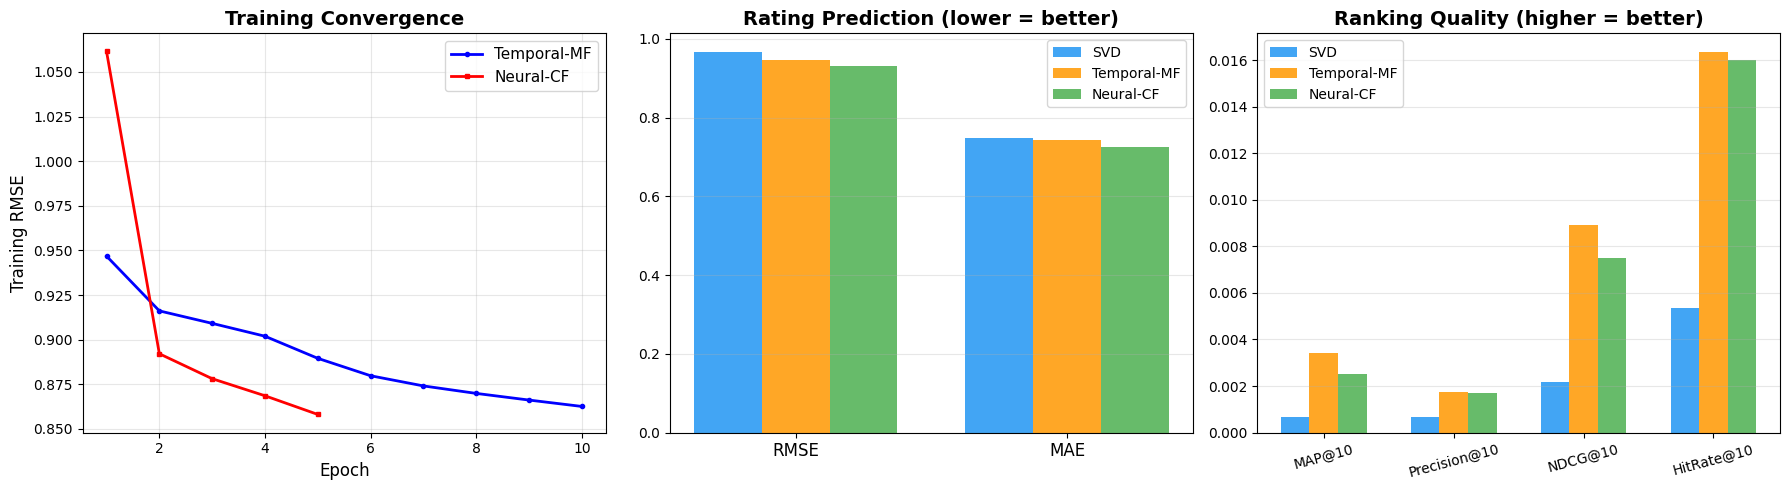


Plot saved as model_comparison.png

  FINAL RESULT: Best model is Neural-CF
  Won 4/8 metrics

Full Results (copy-paste friendly):
Model           RMSE       MAE        MAP@10     P@10       R@10       NDCG@10    HR@10      Coverage  
-----------------------------------------------------------------------------------------------
SVD             0.9661     0.7483     0.000653   0.000667   0.002983   0.002187   0.005333   0.041193  
Temporal-MF     0.9471     0.7425     0.003406   0.001733   0.008089   0.008926   0.016333   0.016320  
Neural-CF       0.9307     0.7252     0.002537   0.001700   0.008106   0.007484   0.016000   0.050816  


In [16]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Plot 1: Training convergence curves
ax = axes[0]
if tmf_model.train_loss:
    ax.plot(range(1, len(tmf_model.train_loss)+1), tmf_model.train_loss,
            'b-o', markersize=3, label='Temporal-MF', linewidth=2)
if ncf_model.train_loss:
    ax.plot(range(1, len(ncf_model.train_loss)+1), ncf_model.train_loss,
            'r-s', markersize=3, label='Neural-CF', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Training RMSE', fontsize=12)
ax.set_title('Training Convergence', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Plot 2: Rating prediction metrics (lower is better)
ax = axes[1]
pred_metrics = ['RMSE', 'MAE']
x = np.arange(len(pred_metrics))
width = 0.25
colors = ['#2196F3', '#FF9800', '#4CAF50']
for i, name in enumerate(model_names):
    vals = [results[name][m] for m in pred_metrics]
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(pred_metrics, fontsize=12)
ax.set_title('Rating Prediction (lower = better)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Ranking metrics (higher is better)
ax = axes[2]
rank_metrics = ['MAP@10', 'Precision@10', 'NDCG@10', 'HitRate@10']
x = np.arange(len(rank_metrics))
width = 0.22
for i, name in enumerate(model_names):
    vals = [results[name][m] for m in rank_metrics]
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(rank_metrics, fontsize=10, rotation=15)
ax.set_title('Ranking Quality (higher = better)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as model_comparison.png")

# --- Final Summary ---
print("\n" + "=" * 70)
print(f"  FINAL RESULT: Best model is {overall_winner}")
print(f"  Won {best_scores[overall_winner]}/{len(metrics_list)} metrics")
print("=" * 70)

# Print full results table for easy copying
print("\nFull Results (copy-paste friendly):")
print(f"{'Model':<15} {'RMSE':<10} {'MAE':<10} {'MAP@10':<10} "
      f"{'P@10':<10} {'R@10':<10} {'NDCG@10':<10} {'HR@10':<10} {'Coverage':<10}")
print("-" * 95)
for name in model_names:
    r = results[name]
    print(f"{name:<15} {r['RMSE']:<10.4f} {r['MAE']:<10.4f} {r['MAP@10']:<10.6f} "
          f"{r['Precision@10']:<10.6f} {r['Recall@10']:<10.6f} {r['NDCG@10']:<10.6f} "
          f"{r['HitRate@10']:<10.6f} {r['Coverage']:<10.6f}")


In [18]:

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("\n" + "=" * 70)
print("  IDENTIFYING SIMILARITIES (Item-Item Collaborative Filtering)")
print("=" * 70)

# Consistent with overall_winner from Cell 9/11
best_model_name = overall_winner
best_model = models[best_model_name]

# Extract learned item representations safely based on the winning architecture
if best_model_name == 'Neural-CF':
    item_factors = best_model.model.item_embed.weight.detach().cpu().numpy()
elif best_model_name == 'Temporal-MF':
    item_factors = best_model.Q
else: # SVD
    item_factors = best_model.Vt.T

movie_to_idx = data['movie_to_idx']
idx_to_movie = data['idx_to_movie']
df_movies = data['df_movies']

# Pick a few sample movies that actually exist in your processed subset index
sample_movie_ids = list(movie_to_idx.keys())[:3]

for target_movie_id in sample_movie_ids:
    target_idx = movie_to_idx[target_movie_id]
    target_vector = item_factors[target_idx].reshape(1, -1)

    # Compute vector cosine distance across latent spaces
    similarities = cosine_similarity(target_vector, item_factors).flatten()

    # Get top 5 most similar indices (excluding the movie itself)
    similar_indices = np.argsort(similarities)
    similar_indices = [idx for idx in similar_indices if idx != target_idx][-5:][::-1]

    # Safely look up movie names from your metadata dataframe
    target_title_series = df_movies[df_movies['Movie_ID'] == target_movie_id]['Title']
    if len(target_title_series) > 0:
        target_title = target_title_series.values[0]
    else:
        target_title = f"Movie ID {target_movie_id}"

    print(f"\nBecause you watched: '{target_title}'")
    print("  Our system recommends these similar titles:")

    for rank, idx in enumerate(similar_indices, 1):
        sim_score = similarities[idx]
        mid = idx_to_movie[idx]

        title_series = df_movies[df_movies['Movie_ID'] == mid]['Title']
        title = title_series.values[0] if len(title_series) > 0 else f"Movie ID {mid}"
        print(f"    {rank}. {title:<45s} (Match: {sim_score*100:5.1f}%)")


  IDENTIFYING SIMILARITIES (Item-Item Collaborative Filtering)

Because you watched: 'Dinosaur Planet'
  Our system recommends these similar titles:
    1. Dinner at Eight                               (Match:  93.0%)
    2. When It Was a Game                            (Match:  92.2%)
    3. Beau Geste                                    (Match:  92.0%)
    4. Dave Mason: Live at Sunrise                   (Match:  92.0%)
    5. Chef!: Series 1                               (Match:  91.9%)

Because you watched: 'Isle of Man TT 2004 Review'
  Our system recommends these similar titles:
    1. Goo Goo Dolls: Live in Buffalo                (Match:  95.4%)
    2. The Best of Riverdance                        (Match:  93.0%)
    3. Jeff Foxworthy: You Might Be a Redneck / Check Your Neck (Match:  91.2%)
    4. Jeff Foxworthy: Totally Committed             (Match:  90.7%)
    5. Ivan Vasilievich: Back to the Future          (Match:  90.6%)

Because you watched: 'Character'
  Our system recom

In [19]:
print("\n" + "=" * 70)
print("  HANDLING COLD START (New Users with 0 History)")
print("=" * 70)
if 'Temporal-MF' in models:
    item_biases = models['Temporal-MF'].b_i
elif 'SVD' in models:
    item_biases = models['SVD'].item_bias
else:
    item_biases = np.zeros(n_movies)
# We also want movies that are well-known (high number of ratings) to ensure safe recommendations
movie_counts = data['train_data']['movie_idx'].value_counts()
popular_movie_indices = movie_counts[movie_counts > 5000].index.values
# Calculate exact global mean rating for each movie to prove popularity
movie_means = data['train_data'].groupby('movie_idx')['Rating'].mean()
# Filter biases to only include popular movies, then sort
popular_biases = {idx: item_biases[idx] for idx in popular_movie_indices}
top_cold_start_indices = sorted(popular_biases, key=popular_biases.get, reverse=True)[:5]
print("Simulating a brand new user (User ID: 999999999) with ZERO historical ratings.")
print("Falling back to Global Popularity / Demographic recommendations:\n")
for rank, idx in enumerate(top_cold_start_indices, 1):
    mid = data['idx_to_movie'][idx]
    title = data['df_movies'][data['df_movies']['Movie_ID'] == mid]['Title'].values[0]

    # Justification metrics
    total_ratings = movie_counts[idx]
    avg_rating = movie_means[idx]

    print(f"  {rank}. {title}")
    print(f"     [Justification: Universally Acclaimed — Rated {total_ratings:,} times with an Average Score of {avg_rating:.2f}/5.0]")



  HANDLING COLD START (New Users with 0 History)
Simulating a brand new user (User ID: 999999999) with ZERO historical ratings.
Falling back to Global Popularity / Demographic recommendations:

  1. Lord of the Rings: The Two Towers: Extended Edition
     [Justification: Universally Acclaimed — Rated 8,833 times with an Average Score of 4.72/5.0]
  2. Lord of the Rings: The Return of the King: Extended Edition
     [Justification: Universally Acclaimed — Rated 8,753 times with an Average Score of 4.73/5.0]
  3. The Lord of the Rings: The Fellowship of the Ring: Extended Edition
     [Justification: Universally Acclaimed — Rated 8,634 times with an Average Score of 4.73/5.0]
  4. The Shawshank Redemption: Special Edition
     [Justification: Universally Acclaimed — Rated 16,408 times with an Average Score of 4.60/5.0]
  5. Lord of the Rings: The Return of the King
     [Justification: Universally Acclaimed — Rated 15,967 times with an Average Score of 4.56/5.0]
